In [19]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_recall_curve, roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score
)
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [20]:
# 1. Load RAW data for GRU-D
df_a_raw = pd.read_csv('data_part1.csv')
df_b_raw = pd.read_csv('data_part2.csv')

if 'Gender' in df_a_raw.columns and 'Gender_1' not in df_a_raw.columns:
    df_a_raw['Gender_1'] = df_a_raw['Gender']
    df_b_raw['Gender_1'] = df_b_raw['Gender']

# 2. Load PRE-COMPUTED Tabular features for XGBoost
df_a_xgb = pd.read_csv('hospA_xgb_features.csv')

# -> Attach the perfectly reconstructed Patient_IDs to fix the KeyError <-
df_a_xgb['Patient_ID'] = pd.read_csv('recovered_pids.csv')['Patient_ID']

# Ensure patient pools match exactly
patient_ids = df_a_raw['Patient_ID'].unique()

# Synchronized Splits (80/20 Test, 90/10 Internal)
train_val_pids, test_pids = train_test_split(patient_ids, test_size=0.20, random_state=SEED)
train_pids, val_pids = train_test_split(train_val_pids, test_size=0.10, random_state=SEED)

print(f"Train patients: {len(train_pids)} | Meta-Val: {len(val_pids)} | Test A: {len(test_pids)}")

Train patients: 14641 | Meta-Val: 1627 | Test A: 4068


/var/folders/ty/w9p6kyt947d7qkgwpyhq55ww0000gn/T/ipykernel_46243/4192511745.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_a_xgb['Patient_ID'] = pd.read_csv('recovered_pids.csv')['Patient_ID']


In [21]:
# Filter tabular data by patient splits
X_tr_xgb  = df_a_xgb[df_a_xgb['Patient_ID'].isin(train_pids)].copy()
X_val_xgb = df_a_xgb[df_a_xgb['Patient_ID'].isin(val_pids)].copy()
X_tea_xgb = df_a_xgb[df_a_xgb['Patient_ID'].isin(test_pids)].copy()

# Extract labels
y_tr_xgb  = X_tr_xgb.pop('SepsisLabel')
y_val_xgb = X_val_xgb.pop('SepsisLabel')
y_tea_xgb = X_tea_xgb.pop('SepsisLabel')

key_val = X_val_xgb[['Patient_ID', 'ICULOS']].copy()
key_tea = X_tea_xgb[['Patient_ID', 'ICULOS']].copy()
drop_cols = ['Patient_ID', 'Unit1', 'Unit2', 'Unit', 'Hour']
for df in [X_tr_xgb, X_val_xgb, X_tea_xgb]:
    df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

# Calculate pos_weight
pw = (len(y_tr_xgb) - y_tr_xgb.sum()) / y_tr_xgb.sum()

print("Training XGBoost Base Model...")
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=pw, eval_metric='aucpr', random_state=SEED,
    max_depth=4, learning_rate=0.03, n_estimators=1049, 
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    tree_method='hist', n_jobs=-1
)
xgb_model.fit(X_tr_xgb, y_tr_xgb)

# Get raw probabilities on Meta-Val fold
p_xgb_val_raw = xgb_model.predict_proba(X_val_xgb)[:, 1]
p_xgb_tea_raw = xgb_model.predict_proba(X_tea_xgb)[:, 1]
print(f"XGBoost Meta-Val AUPRC: {average_precision_score(y_val_xgb, p_xgb_val_raw):.4f}")

Training XGBoost Base Model...
XGBoost Meta-Val AUPRC: 0.0934


In [22]:
VITALS = ['HR', 'O2Sat', 'Temp', 'MAP', 'Resp']
LABS = ['BUN', 'Chloride', 'Creatinine', 'Glucose', 'Hct', 'Hgb', 'WBC', 'Platelets']
STATICS = ['Age', 'Gender_1', 'ICULOS', 'HospAdmTime']
RAW_FEATURES = VITALS + LABS + STATICS
D_OBS = len(VITALS) + len(LABS); D_FULL = len(RAW_FEATURES)

def build_patient_tensors(df_cohort, max_seq_len=168):
    seqs_X, seqs_M, seqs_Delta, seqs_X_last, seqs_y = [], [], [], [], []
    for pid, grp in df_cohort.groupby('Patient_ID'):
        grp = grp.sort_values('ICULOS')
        if len(grp) > max_seq_len: grp = grp.tail(max_seq_len)
        T = len(grp)
        X_p = np.zeros((T, D_FULL), dtype=np.float32)
        M_p = np.zeros((T, D_OBS), dtype=np.float32)
        Delta_p = np.zeros((T, D_OBS), dtype=np.float32)
        X_last_p = np.zeros((T, D_OBS), dtype=np.float32)
        
        for i, col in enumerate(STATICS): X_p[:, D_OBS + i] = grp[col].values
        for d, col in enumerate(VITALS + LABS):
            vals = grp[col].values
            m = pd.notna(vals).astype(np.float32)
            M_p[:, d] = m
            X_p[:, d] = np.where(m == 1, vals, 0.0)
            last_obs = np.nan 
            for t in range(T):
                Delta_p[t, d] = 0.0 if t == 0 else (1.0 if M_p[t-1, d] == 1 else Delta_p[t-1, d] + 1.0)
                X_last_p[t, d] = last_obs
                if m[t] == 1: last_obs = vals[t]
        y_p = grp['SepsisLabel'].values.astype(np.float32)
        seqs_X.append(X_p); seqs_M.append(M_p); seqs_Delta.append(Delta_p); seqs_X_last.append(X_last_p); seqs_y.append(y_p)
    return seqs_X, seqs_M, seqs_Delta, seqs_X_last, seqs_y

print("Building GRU Tensors...")
tr_X, tr_M, tr_Delta, tr_X_last, tr_y = build_patient_tensors(df_a_raw[df_a_raw['Patient_ID'].isin(train_pids)])
val_X, val_M, val_Delta, val_X_last, val_y = build_patient_tensors(df_a_raw[df_a_raw['Patient_ID'].isin(val_pids)])
tea_X, tea_M, tea_Delta, tea_X_last, tea_y = build_patient_tensors(df_a_raw[df_a_raw['Patient_ID'].isin(test_pids)])

flat_tr_X, flat_tr_M = np.concatenate(tr_X, axis=0), np.concatenate(tr_M, axis=0)
means, stds = np.zeros(D_FULL, dtype=np.float32), np.ones(D_FULL, dtype=np.float32)

for d in range(D_OBS):
    obs_vals = flat_tr_X[flat_tr_M[:, d] == 1, d]
    if len(obs_vals) > 0: means[d], stds[d] = obs_vals.mean(), obs_vals.std() + 1e-6
for i in range(D_OBS, D_FULL): means[i], stds[i] = flat_tr_X[:, i].mean(), flat_tr_X[:, i].std() + 1e-6

def apply_normalization(seqs_X, seqs_X_last, seqs_M):
    norm_X, norm_X_last = [], []
    for X_p, X_last_p, M_p in zip(seqs_X, seqs_X_last, seqs_M):
        X_norm = (X_p - means) / stds
        for d in range(D_OBS): X_norm[:, d] = np.where(M_p[:, d] == 1, X_norm[:, d], 0.0)
        X_norm = np.nan_to_num(X_norm, nan=0.0)
        X_last_norm = np.nan_to_num((X_last_p - means[:D_OBS]) / stds[:D_OBS], nan=0.0) 
        norm_X.append(X_norm); norm_X_last.append(X_last_norm)
    return norm_X, norm_X_last

tr_X, tr_X_last = apply_normalization(tr_X, tr_X_last, tr_M)
val_X, val_X_last = apply_normalization(val_X, val_X_last, val_M)
tea_X, tea_X_last = apply_normalization(tea_X, tea_X_last, tea_M)

Building GRU Tensors...


In [23]:
# class GRUDDataset(Dataset):
#     def __init__(self, X, M, Delta, X_last, y):
#         self.X, self.M, self.Delta, self.X_last, self.y = X, M, Delta, X_last, y
#         self.lengths = [len(seq) for seq in X]
#     def __len__(self): return len(self.X)
#     def __getitem__(self, idx):
#         return (torch.tensor(self.X[idx], dtype=torch.float32), torch.tensor(self.M[idx], dtype=torch.float32),
#                 torch.tensor(self.Delta[idx], dtype=torch.float32), torch.tensor(self.X_last[idx], dtype=torch.float32),
#                 torch.tensor(self.y[idx], dtype=torch.float32), self.lengths[idx])

# def collate_fn(batch):
#     Xs, Ms, Deltas, X_lasts, ys, lengths = zip(*batch)
#     X_pad = torch.nn.utils.rnn.pad_sequence(Xs, batch_first=True, padding_value=0.0)
#     M_pad = torch.nn.utils.rnn.pad_sequence(Ms, batch_first=True, padding_value=0.0)
#     Delta_pad = torch.nn.utils.rnn.pad_sequence(Deltas, batch_first=True, padding_value=0.0)
#     X_last_pad = torch.nn.utils.rnn.pad_sequence(X_lasts, batch_first=True, padding_value=0.0)
#     y_pad = torch.nn.utils.rnn.pad_sequence(ys, batch_first=True, padding_value=0.0)
#     return X_pad, M_pad, Delta_pad, X_last_pad, y_pad, torch.tensor(lengths, dtype=torch.long)

# train_loader = DataLoader(GRUDDataset(tr_X, tr_M, tr_Delta, tr_X_last, tr_y),
#                           batch_size=64, shuffle=True,  collate_fn=collate_fn)
# val_loader   = DataLoader(GRUDDataset(val_X, val_M, val_Delta, val_X_last, val_y),
#                           batch_size=64, shuffle=False, collate_fn=collate_fn)
# tea_loader   = DataLoader(GRUDDataset(tea_X, tea_M, tea_Delta, tea_X_last, tea_y),
#                           batch_size=64, shuffle=False, collate_fn=collate_fn)

# class GRUDCell(nn.Module):
#     def __init__(self, input_size, hidden_size, obs_size):
#         super().__init__()
#         self.input_size = input_size
#         self.hidden_size = hidden_size
#         self.obs_size = obs_size

#         # Decay params. W_gamma_x is element-wise (diagonal per paper §2.2).
#         # Bias init small-positive so initial gamma is slightly < 1, not exactly 1.
#         self.W_gamma_x = nn.Parameter(torch.zeros(obs_size))
#         self.b_gamma_x = nn.Parameter(torch.full((obs_size,), 0.01))
#         self.W_gamma_h = nn.Parameter(torch.zeros(hidden_size, obs_size))
#         self.b_gamma_h = nn.Parameter(torch.full((hidden_size,), 0.01))

#         self.W_z = nn.Linear(input_size, hidden_size)
#         self.U_z = nn.Linear(hidden_size, hidden_size, bias=False)
#         self.V_z = nn.Linear(obs_size, hidden_size, bias=False)

#         self.W_r = nn.Linear(input_size, hidden_size)
#         self.U_r = nn.Linear(hidden_size, hidden_size, bias=False)
#         self.V_r = nn.Linear(obs_size, hidden_size, bias=False)

#         self.W = nn.Linear(input_size, hidden_size)
#         self.U = nn.Linear(hidden_size, hidden_size, bias=False)
#         self.V = nn.Linear(obs_size, hidden_size, bias=False)

#         # Smaller init on gate/cell linear maps reduces early-training logit magnitude.
#         for lin in [self.W_z, self.W_r, self.W, self.U_z, self.U_r, self.U, self.V_z, self.V_r, self.V]:
#             nn.init.xavier_uniform_(lin.weight, gain=0.5)
#             if lin.bias is not None:
#                 nn.init.zeros_(lin.bias)

#     def forward(self, x, m, delta, x_last, h_prev, rec_mask=None):
#         # Clamp delta to a safe range. 168h cap is enforced upstream but defensive.
#         delta = torch.clamp(delta, max=200.0)

#         gamma_x = torch.exp(-torch.relu(self.W_gamma_x * delta + self.b_gamma_x))
#         gamma_h = torch.exp(-torch.relu(F.linear(delta, self.W_gamma_h, self.b_gamma_h)))

#         x_obs = x[:, :self.obs_size]
#         x_imputed = m * x_obs + (1 - m) * (gamma_x * x_last)
#         x_full = torch.cat([x_imputed, x[:, self.obs_size:]], dim=1)

#         h_prev_decayed = gamma_h * h_prev
#         if rec_mask is not None:
#             h_prev_decayed = h_prev_decayed * rec_mask

#         z = torch.sigmoid(self.W_z(x_full) + self.U_z(h_prev_decayed) + self.V_z(m))
#         r = torch.sigmoid(self.W_r(x_full) + self.U_r(h_prev_decayed) + self.V_r(m))
#         h_tilde = torch.tanh(self.W(x_full) + self.U(r * h_prev_decayed) + self.V(m))

#         return (1 - z) * h_prev_decayed + z * h_tilde


# class GRUDModel(nn.Module):
#     def __init__(self, input_size=17, hidden_size=64, obs_size=13, drop=0.3):
#         super().__init__()
#         self.hidden_size = hidden_size
#         self.cell = GRUDCell(input_size, hidden_size, obs_size)
#         self.drop = drop
#         self.classifier = nn.Sequential(nn.Dropout(0.5), nn.Linear(hidden_size, 1))
#         # Small init on classifier so initial logits are O(1), not O(10).
#         nn.init.xavier_uniform_(self.classifier[1].weight, gain=0.1)
#         nn.init.zeros_(self.classifier[1].bias)

#     def forward(self, X, M, Delta, X_last):
#         B, T, _ = X.size()
#         h = torch.zeros(B, self.hidden_size, device=X.device)

#         # Variational recurrent dropout: one mask per sequence, shared across t.
#         if self.training and self.drop > 0:
#             rec_mask = (torch.rand(B, self.hidden_size, device=X.device) > self.drop).float() / (1 - self.drop)
#         else:
#             rec_mask = None

#         outputs = []
#         for t in range(T):
#             h = self.cell(X[:, t, :], M[:, t, :], Delta[:, t, :], X_last[:, t, :], h, rec_mask)
#             outputs.append(h.unsqueeze(1))

#         outputs = torch.cat(outputs, dim=1)
#         logits = self.classifier(outputs).squeeze(-1)
#         # Clamp logits before BCE. With pos_weight=44, loss = pw * softplus(-logit) for pos
#         # and softplus(logit) for neg — clamping at +/-15 keeps loss in a sane range.
#         return torch.clamp(logits, min=-15.0, max=15.0)


# gru_model = GRUDModel().to(device)
# n_pos = sum((y == 1).sum() for y in tr_y)
# n_neg = sum((y == 0).sum() for y in tr_y)
# pw = torch.tensor([n_neg / (n_pos + 1e-6)], dtype=torch.float32).to(device)
# criterion = nn.BCEWithLogitsLoss(pos_weight=pw)
# optimizer = torch.optim.Adam(gru_model.parameters(), lr=5e-4, weight_decay=1e-5)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

# WARMUP_STEPS = 200
# global_step = 0
# EPOCHS = 25
# best_val_auprc, patience_counter = 0.0, 0

# print("Training GRU-D Base Model with early stopping...")
# for ep in range(1, EPOCHS + 1):
#     gru_model.train()
#     for Xb, Mb, Db, Xlb, yb, Lb in train_loader:
#         Xb, Mb, Db, Xlb, yb, Lb = [v.to(device) for v in (Xb, Mb, Db, Xlb, yb, Lb)]
#         if global_step < WARMUP_STEPS:
#             for pg in optimizer.param_groups:
#                 pg['lr'] = 5e-4 * (global_step + 1) / WARMUP_STEPS
#         optimizer.zero_grad()
#         logits = gru_model(Xb, Mb, Db, Xlb)
#         mask = (torch.arange(logits.size(1)).unsqueeze(0).to(device) < Lb.unsqueeze(1))
#         loss = criterion(logits[mask], yb[mask])
#         if not torch.isfinite(loss):
#             global_step += 1; continue
#         loss.backward()
#         nn.utils.clip_grad_norm_(gru_model.parameters(), 1.0)
#         optimizer.step()
#         global_step += 1

#     # Val AUPRC for early stopping
#     gru_model.eval()
#     val_probs, val_lbls = [], []
#     with torch.no_grad():
#         for Xb, Mb, Db, Xlb, yb, Lb in val_loader:
#             logits = gru_model(*[v.to(device) for v in (Xb, Mb, Db, Xlb)])
#             probs = torch.sigmoid(logits).cpu().numpy()
#             for i, L in enumerate(Lb.numpy()):
#                 val_probs.append(probs[i, :L])
#                 val_lbls.append(yb[i, :L].numpy())
#     all_val_probs = np.concatenate(val_probs)
#     all_val_lbls  = np.concatenate(val_lbls)
#     val_auprc = average_precision_score(all_val_lbls, all_val_probs)
#     scheduler.step(val_auprc)
#     print(f'Epoch {ep:2d} | Val AUPRC: {val_auprc:.4f}')

#     if val_auprc > best_val_auprc:
#         best_val_auprc = val_auprc; patience_counter = 0
#         torch.save(gru_model.state_dict(), 'grud_ensemble_best.pt')
#     else:
#         patience_counter += 1
#         if patience_counter >= 5:
#             print("Early stopping."); break
# gru_model.load_state_dict(torch.load('grud_ensemble_best.pt'))

# def get_gru_probs_aligned(loader, dataset_pids):
#     """Returns concatenated per-timestep probs in (pid, t) order, plus the index keys."""
#     gru_model.eval()
#     out_probs, out_keys = [], []
#     cursor = 0  # walks dataset_pids in batch order (shuffle=False, no sort)
#     with torch.no_grad():
#         for Xb, Mb, Db, Xlb, yb, Lb in loader:
#             logits = gru_model(*[v.to(device) for v in (Xb, Mb, Db, Xlb)])
#             probs = torch.sigmoid(logits).cpu().numpy()
#             for i, L in enumerate(Lb.numpy()):
#                 pid = dataset_pids[cursor]
#                 for t in range(L):
#                     out_probs.append(probs[i, t])
#                     out_keys.append((pid, t))
#                 cursor += 1
#     return np.array(out_probs), out_keys

# # Build per-loader patient-id lists in dataset order. The build_patient_tensors
# # function iterates df_cohort.groupby('Patient_ID'), so the ordering is
# # numpy-sort of unique Patient_IDs in the cohort frame.
# val_pid_order = sorted(df_a_raw[df_a_raw['Patient_ID'].isin(val_pids)]['Patient_ID'].unique())
# tea_pid_order = sorted(df_a_raw[df_a_raw['Patient_ID'].isin(test_pids)]['Patient_ID'].unique())

# # pandas groupby sorts by key by default — confirm with sorted() above.
# p_gru_val_raw, val_keys = get_gru_probs_aligned(val_loader, val_pid_order)
# p_gru_tea_raw, tea_keys = get_gru_probs_aligned(tea_loader, tea_pid_order)

# print(f"GRU val probs: {len(p_gru_val_raw)}, test probs: {len(p_gru_tea_raw)}")

In [24]:
# Load GRU-D probabilities saved by grud_new.ipynb (no retraining here).
gru_val_df = pd.read_csv('grud_val_probs.csv')
gru_tea_df = pd.read_csv('grud_tea_probs.csv')

# These DataFrames already carry (Patient_ID, t_in_patient, prob, label)
# in the canonical order. Extract aligned arrays + key list.
p_gru_val_raw = gru_val_df['prob'].values
p_gru_tea_raw = gru_tea_df['prob'].values
val_keys = list(zip(gru_val_df['Patient_ID'].values, gru_val_df['t_in_patient'].values))
tea_keys = list(zip(gru_tea_df['Patient_ID'].values, gru_tea_df['t_in_patient'].values))

# Labels come straight from the GRU-D probability file too — no realignment needed.
y_val_aln = gru_val_df['label'].values.astype(np.float32)
y_tea_aln = gru_tea_df['label'].values.astype(np.float32)

print(f"GRU val probs: {len(p_gru_val_raw)}, test probs: {len(p_gru_tea_raw)}")

GRU val probs: 63233, test probs: 155092


In [25]:
import pandas as pd

def derive_t_in_patient(key_df):
    """For each row, compute its 0-indexed timestep within its patient (after the
    same 168h tail-truncation the GRU side does)."""
    out = key_df.copy()
    out = out.sort_values(['Patient_ID', 'ICULOS']).reset_index(drop=True)
    # mimic build_patient_tensors: keep last 168 timesteps per patient
    out['rev_idx'] = out.groupby('Patient_ID').cumcount(ascending=False)
    out = out[out['rev_idx'] < 168].copy()
    out['t_in_patient'] = out.groupby('Patient_ID').cumcount()
    return out.drop(columns=['rev_idx'])

def reindex_xgb(probs_raw, key_df, original_index):
    """Drop XGB rows that were truncated out of the 168h window, returning probs
    aligned to (pid, t)."""
    aligned = derive_t_in_patient(key_df.assign(_orig=original_index))
    keep_idx = aligned['_orig'].values
    probs_kept = probs_raw[keep_idx]
    keys = list(zip(aligned['Patient_ID'].values, aligned['t_in_patient'].values))
    return probs_kept, keys

p_xgb_val_aln, xgb_val_keys = reindex_xgb(p_xgb_val_raw, key_val, np.arange(len(key_val)))
p_xgb_tea_aln, xgb_tea_keys = reindex_xgb(p_xgb_tea_raw, key_tea, np.arange(len(key_tea)))

# Sanity check before fitting calibrators
assert xgb_val_keys == val_keys, "Val alignment failed — keys differ"
assert xgb_tea_keys == tea_keys, "Test alignment failed — keys differ"

# # Aligned labels: get y in the same (pid, t) order
# def aligned_labels(df_raw, key_order):
#     """Look up SepsisLabel for each (pid, t) using df_raw."""
#     df_sorted = df_raw.sort_values(['Patient_ID', 'ICULOS']).reset_index(drop=True)
#     df_sorted['rev_idx'] = df_sorted.groupby('Patient_ID').cumcount(ascending=False)
#     df_sorted = df_sorted[df_sorted['rev_idx'] < 168].copy()
#     df_sorted['t_in_patient'] = df_sorted.groupby('Patient_ID').cumcount()
#     lut = df_sorted.set_index(['Patient_ID', 't_in_patient'])['SepsisLabel']
#     return np.array([lut.loc[k] for k in key_order], dtype=np.float32)

# y_val_aln = aligned_labels(df_a_raw[df_a_raw['Patient_ID'].isin(val_pids)], val_keys)
# y_tea_aln = aligned_labels(df_a_raw[df_a_raw['Patient_ID'].isin(test_pids)], tea_keys)

print("Calibrating Probabilities using Isotonic Regression...")
iso_xgb = IsotonicRegression(out_of_bounds='clip')
p_xgb_val_cal = iso_xgb.fit_transform(p_xgb_val_aln, y_val_aln)
p_xgb_tea_cal = iso_xgb.transform(p_xgb_tea_aln)

iso_gru = IsotonicRegression(out_of_bounds='clip')
p_gru_val_cal = iso_gru.fit_transform(p_gru_val_raw, y_val_aln)
p_gru_tea_cal = iso_gru.transform(p_gru_tea_raw)

rho = np.corrcoef(p_xgb_val_cal, p_gru_val_cal)[0, 1]
print(f"Model Correlation (rho) on val: {rho:.4f}  (lower = more diverse, better)")

X_stack_val = np.column_stack((p_xgb_val_cal, p_gru_val_cal))
stacker = LogisticRegression()
stacker.fit(X_stack_val, y_val_aln)
print("Stacker Weights:", stacker.coef_[0])

Calibrating Probabilities using Isotonic Regression...
Model Correlation (rho) on val: 0.8079  (lower = more diverse, better)
Stacker Weights: [8.01575356 9.32109749]


In [26]:
X_stack_tea = np.column_stack((p_xgb_tea_cal, p_gru_tea_cal))
p_ensemble_tea = stacker.predict_proba(X_stack_tea)[:, 1]

def evaluate(y_true, y_prob, name):
    precs, recs, ths = precision_recall_curve(y_true, y_prob)
    f1s = 2 * (precs[:-1] * recs[:-1]) / (precs[:-1] + recs[:-1] + 1e-8)
    opt_th = ths[np.argmax(f1s)]
    clin_th = next((ths[i] for i in range(len(recs)-1) if recs[i] >= 0.6 and recs[i+1] < 0.6), 0.5)
    print(f"\n{'='*40}\n{name} — Final Test Results\n{'='*40}")
    print(f"AUROC: {roc_auc_score(y_true, y_prob):.4f}")
    print(f"AUPRC: {average_precision_score(y_true, y_prob):.4f}\n")
    for t_name, th in [("Optimal F1", opt_th), ("Clinical (>=60% Recall)", clin_th)]:
        preds = (y_prob >= th).astype(int)
        print(f"[{t_name}] Thresh: {th:.4f} | Prec: {precision_score(y_true,preds,zero_division=0):.4f} | "
              f"Rec: {recall_score(y_true,preds):.4f} | F1: {f1_score(y_true,preds):.4f}")

# Compare ensemble against each base on the same aligned labels.
evaluate(y_tea_aln, p_xgb_tea_cal,  "XGBoost (calibrated, alone)")
evaluate(y_tea_aln, p_gru_tea_cal,  "GRU-D (calibrated, alone)")
evaluate(y_tea_aln, p_ensemble_tea, "XGBoost + GRU-D Ensemble (Hospital A)")


XGBoost (calibrated, alone) — Final Test Results
AUROC: 0.8024
AUPRC: 0.1034

[Optimal F1] Thresh: 0.0864 | Prec: 0.1600 | Rec: 0.3008 | F1: 0.2089
[Clinical (>=60% Recall)] Thresh: 0.0249 | Prec: 0.0658 | Rec: 0.6361 | F1: 0.1193

GRU-D (calibrated, alone) — Final Test Results
AUROC: 0.7885
AUPRC: 0.0949

[Optimal F1] Thresh: 0.1115 | Prec: 0.1776 | Rec: 0.2131 | F1: 0.1937
[Clinical (>=60% Recall)] Thresh: 0.0276 | Prec: 0.0598 | Rec: 0.6345 | F1: 0.1093

XGBoost + GRU-D Ensemble (Hospital A) — Final Test Results
AUROC: 0.8089
AUPRC: 0.1097

[Optimal F1] Thresh: 0.0580 | Prec: 0.1722 | Rec: 0.2796 | F1: 0.2131
[Clinical (>=60% Recall)] Thresh: 0.0201 | Prec: 0.0710 | Rec: 0.6012 | F1: 0.1270


# Appendix: Presentation Figures
Run this section after running the entire notebook to generate all presentation plots into the `figures/` directory.

In [27]:
import os
os.makedirs('figures', exist_ok=True)

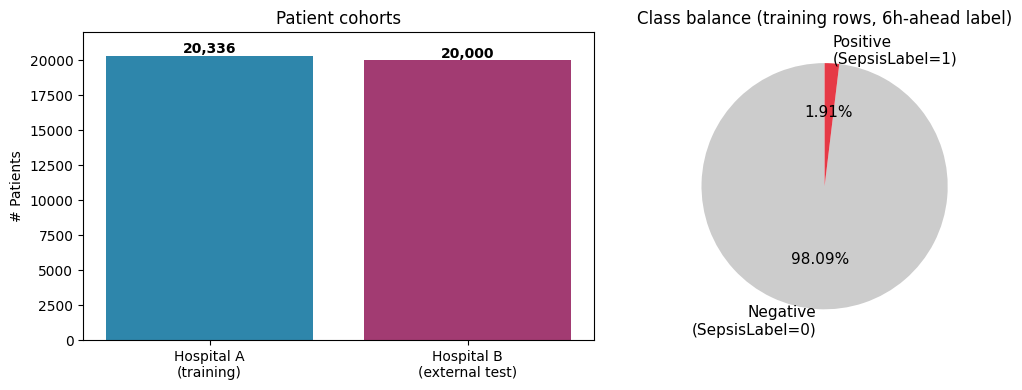

In [28]:
# === FIGURE: dataset_overview.png ===
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Panel A: patients per hospital
hospitals = ['Hospital A\n(training)', 'Hospital B\n(external test)']
counts = [20336, 20000]
axes[0].bar(hospitals, counts, color=['#2E86AB', '#A23B72'])
for i, c in enumerate(counts):
    axes[0].text(i, c + 200, f'{c:,}', ha='center', fontweight='bold')
axes[0].set_ylabel('# Patients')
axes[0].set_title('Patient cohorts')
axes[0].set_ylim(0, 22000)

# Panel B: class imbalance (use actual training counts from sepsis_corrected.ipynb)
# These are row-level counts at the 6h-ahead horizon
labels_imb = ['Negative\n(SepsisLabel=0)', 'Positive\n(SepsisLabel=1)']
sizes = [620852, 12079]   # from cell-26 of sepsis_gru.ipynb output
colors = ['#cccccc', '#E63946']
wedges, texts, autotexts = axes[1].pie(sizes, labels=labels_imb, colors=colors,
                                        autopct='%1.2f%%', startangle=90,
                                        textprops={'fontsize': 11})
axes[1].set_title('Class balance (training rows, 6h-ahead label)')

plt.tight_layout()
plt.savefig('figures/dataset_overview.png', dpi=200, bbox_inches='tight')
plt.show()


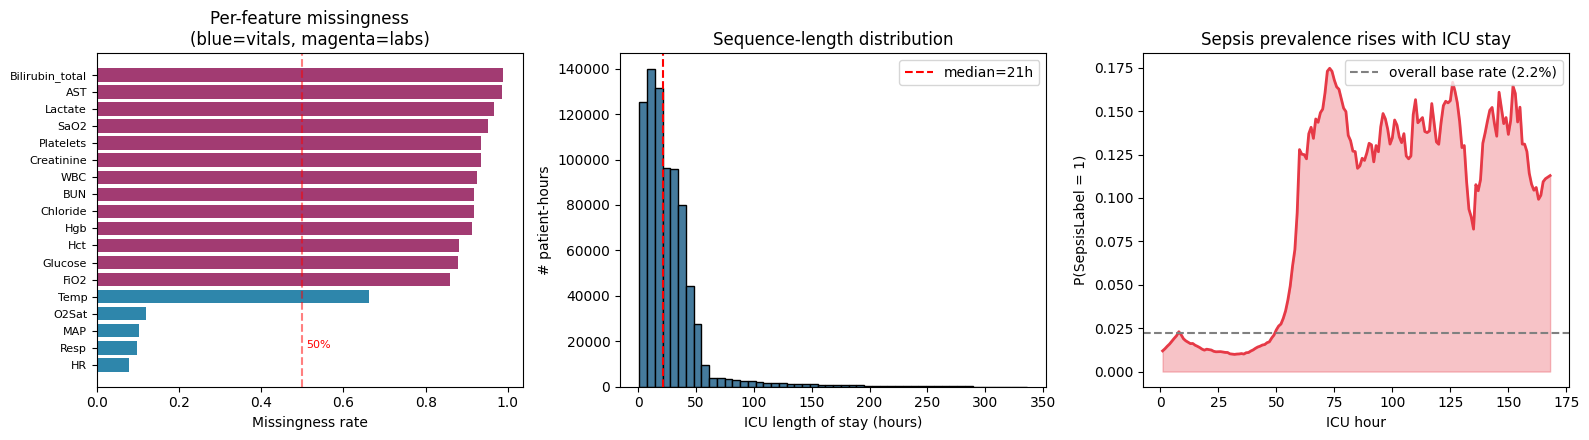

In [29]:
# === FIGURE: dataset_structure.png ===
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Reload raw to get true missingness (run after sepsis_corrected.ipynb)
df = pd.read_csv('data_part1.csv')

VITALS = ['HR','O2Sat','Temp','MAP','Resp']
LABS = ['BUN','Chloride','Creatinine','Glucose','Hct','Hgb','WBC','Platelets',
        'Lactate','Bilirubin_total','AST','SaO2','FiO2']
features = VITALS + LABS

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Panel A: missingness rate per feature
miss_rate = df[features].isna().mean().sort_values()
colors = ['#2E86AB' if c in VITALS else '#A23B72' for c in miss_rate.index]
axes[0].barh(range(len(miss_rate)), miss_rate.values, color=colors)
axes[0].set_yticks(range(len(miss_rate)))
axes[0].set_yticklabels(miss_rate.index, fontsize=8)
axes[0].set_xlabel('Missingness rate')
axes[0].set_title('Per-feature missingness\n(blue=vitals, magenta=labs)')
axes[0].axvline(0.5, color='red', linestyle='--', alpha=0.5)
axes[0].text(0.51, 1, '50%', color='red', fontsize=8)

# Panel B: ICULOS distribution
axes[1].hist(df['ICULOS'].values, bins=50, color='#457B9D', edgecolor='black')
axes[1].axvline(df['ICULOS'].median(), color='red', linestyle='--',
                label=f'median={int(df["ICULOS"].median())}h')
axes[1].set_xlabel('ICU length of stay (hours)')
axes[1].set_ylabel('# patient-hours')
axes[1].set_title('Sequence-length distribution')
axes[1].legend()

# Panel C: sepsis prevalence by ICU hour
prev = df.groupby('ICULOS')['SepsisLabel'].mean()
prev = prev[prev.index <= 168]  # cap at our model window
axes[2].plot(prev.index, prev.values, color='#E63946', linewidth=2)
axes[2].fill_between(prev.index, 0, prev.values, alpha=0.3, color='#E63946')
axes[2].axhline(0.022, color='gray', linestyle='--', label='overall base rate (2.2%)')
axes[2].set_xlabel('ICU hour')
axes[2].set_ylabel('P(SepsisLabel = 1)')
axes[2].set_title('Sepsis prevalence rises with ICU stay')
axes[2].legend()

plt.tight_layout()
plt.savefig('figures/dataset_structure.png', dpi=200, bbox_inches='tight')
plt.show()


Septic patients: 1790


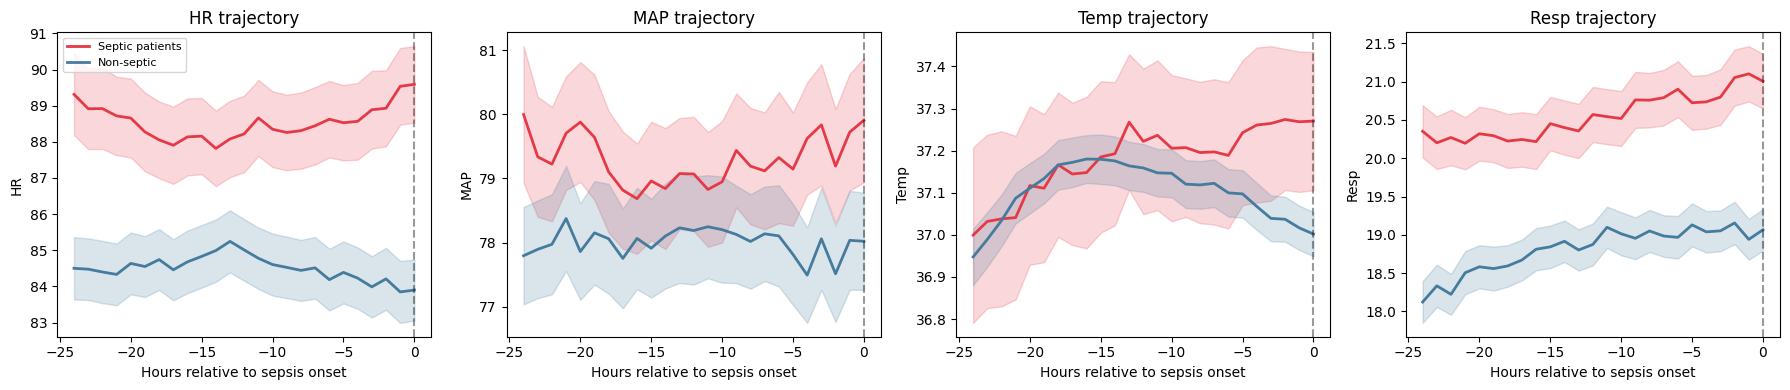

In [30]:
# === FIGURE: vital_trajectories.png ===
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('data_part1.csv').sort_values(['Patient_ID','ICULOS'])

# Find each septic patient's first-positive index
septic_patients = df[df['SepsisLabel']==1].groupby('Patient_ID')['ICULOS'].min()
print(f"Septic patients: {len(septic_patients)}")

# Build aligned-to-onset windows: 24h before through onset
window = 24
panels = ['HR', 'MAP', 'Temp', 'Resp']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, feat in zip(axes, panels):
    septic_curves = []
    for pid, onset_h in septic_patients.items():
        sub = df[(df['Patient_ID']==pid) & (df['ICULOS'] >= onset_h - window)
                 & (df['ICULOS'] <= onset_h)]
        if len(sub) >= 6 and sub[feat].notna().sum() > window // 2:
            vals = sub[feat].ffill().bfill().values
            # pad/truncate to window+1
            if len(vals) >= window + 1:
                septic_curves.append(vals[-(window+1):])
            else:
                septic_curves.append(np.pad(vals, (window+1-len(vals), 0),
                                             mode='edge'))
    septic_curves = np.array(septic_curves)
    mean_s = np.nanmean(septic_curves, axis=0)
    sem_s = np.nanstd(septic_curves, axis=0) / np.sqrt(len(septic_curves))

    # Non-septic baseline: matched random hours from non-septic patients
    nonsept_pids = df[~df['Patient_ID'].isin(septic_patients.index)]['Patient_ID'].unique()
    rng = np.random.default_rng(42)
    sampled = rng.choice(nonsept_pids, size=2000, replace=False)
    nonsept_curves = []
    for pid in sampled:
        sub = df[df['Patient_ID']==pid]
        if len(sub) >= window + 1 and sub[feat].notna().sum() > window // 2:
            t0 = rng.integers(0, len(sub) - window)
            vals = sub[feat].iloc[t0:t0+window+1].ffill().bfill().values
            if len(vals) == window + 1:
                nonsept_curves.append(vals)
    nonsept_curves = np.array(nonsept_curves)
    mean_n = np.nanmean(nonsept_curves, axis=0)
    sem_n = np.nanstd(nonsept_curves, axis=0) / np.sqrt(len(nonsept_curves))

    h = np.arange(-window, 1)
    ax.plot(h, mean_s, color='#E63946', linewidth=2, label='Septic patients')
    ax.fill_between(h, mean_s - 2*sem_s, mean_s + 2*sem_s, alpha=0.2, color='#E63946')
    ax.plot(h, mean_n, color='#457B9D', linewidth=2, label='Non-septic')
    ax.fill_between(h, mean_n - 2*sem_n, mean_n + 2*sem_n, alpha=0.2, color='#457B9D')
    ax.axvline(0, color='black', linestyle='--', alpha=0.4)
    ax.set_xlabel('Hours relative to sepsis onset')
    ax.set_ylabel(feat)
    ax.set_title(f'{feat} trajectory')
    if feat == 'HR':
        ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('figures/vital_trajectories.png', dpi=200, bbox_inches='tight')
plt.show()


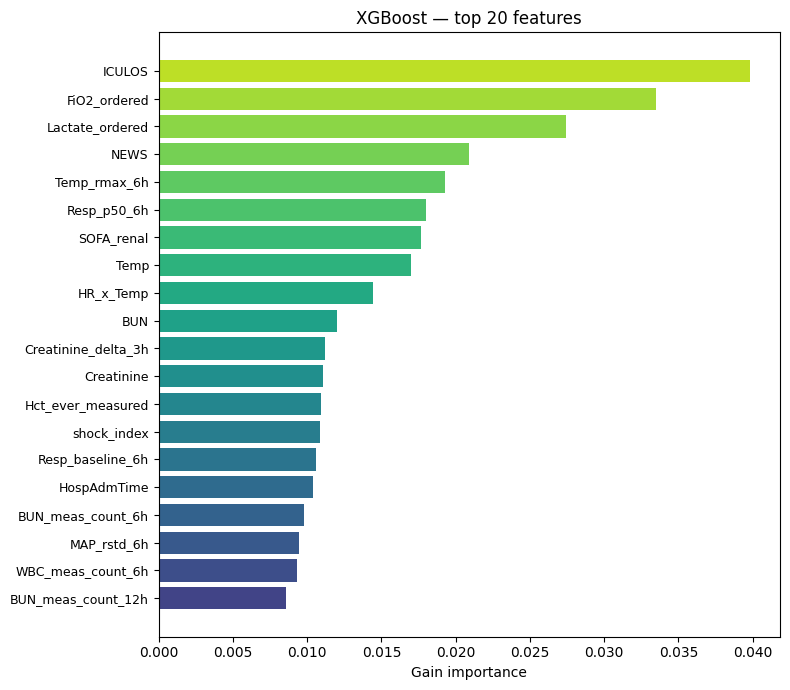

In [31]:
# === FIGURE: xgb_top20.png ===
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# After running sepsis_ensemble.ipynb, xgb_model is in scope
imp = pd.Series(xgb_model.feature_importances_, index=X_tr_xgb.columns)
top = imp.sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(8, 7))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(top)))
ax.barh(range(len(top)), top.values, color=colors)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top.index, fontsize=9)
ax.set_xlabel('Gain importance')
ax.set_title('XGBoost — top 20 features')
plt.tight_layout()
plt.savefig('figures/xgb_top20.png', dpi=200, bbox_inches='tight')
plt.show()


ValueError: Found input variables with inconsistent numbers of samples: [155092, 155929]

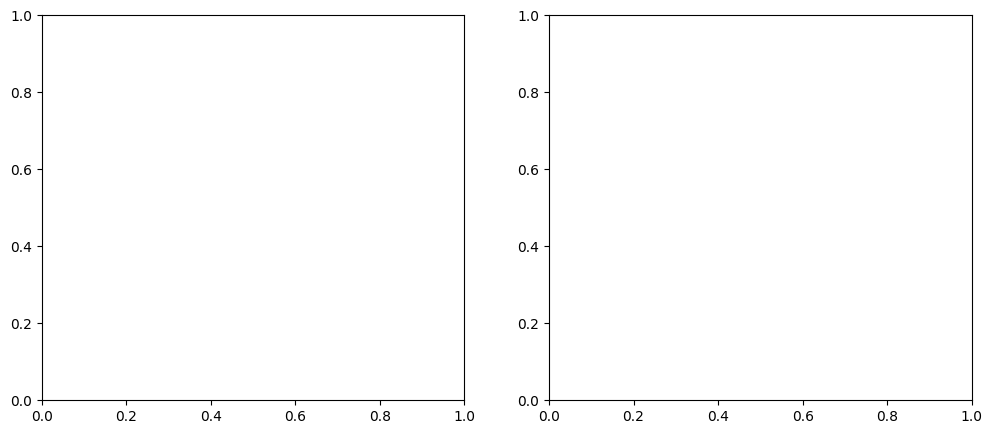

In [32]:
# === FIGURE: ensemble_diagram.png ===
import matplotlib.pyplot as plt
import numpy as np
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A: reliability diagram (before vs after calibration)
for label, p_raw, p_cal, color in [
    ('XGBoost', p_xgb_tea_raw, p_xgb_tea_cal, '#2E86AB'),
    ('GRU-D',   p_gru_tea_raw, p_gru_tea_cal, '#E63946')]:
    frac_raw, mean_raw = calibration_curve(y_tea_aln, p_raw, n_bins=10)
    frac_cal, mean_cal = calibration_curve(y_tea_aln, p_cal, n_bins=10)
    axes[0].plot(mean_raw, frac_raw, '--', color=color, alpha=0.5,
                 label=f'{label} raw')
    axes[0].plot(mean_cal, frac_cal, '-o', color=color,
                 label=f'{label} calibrated')

axes[0].plot([0,1],[0,1], 'k:', alpha=0.5, label='Perfect calibration')
axes[0].set_xlabel('Predicted probability')
axes[0].set_ylabel('Observed frequency')
axes[0].set_title('Calibration improves probability quality')
axes[0].legend(fontsize=8)

# Panel B: stacker decision surface (toy 2D plot of base probs)
xx, yy = np.meshgrid(np.linspace(0,1,100), np.linspace(0,1,100))
grid = np.c_[xx.ravel(), yy.ravel()]
zz = stacker.predict_proba(grid)[:,1].reshape(xx.shape)
im = axes[1].contourf(xx, yy, zz, levels=20, cmap='RdYlGn_r')
plt.colorbar(im, ax=axes[1], label='Ensemble P(sepsis)')
axes[1].scatter(p_xgb_tea_cal[::100], p_gru_tea_cal[::100],
                c=y_tea_aln[::100], s=4, cmap='coolwarm',
                edgecolor='black', linewidth=0.2)
axes[1].set_xlabel('XGBoost calibrated prob')
axes[1].set_ylabel('GRU-D calibrated prob')
axes[1].set_title(f'Stacker: weights=[{stacker.coef_[0,0]:.1f}, {stacker.coef_[0,1]:.1f}]')

plt.tight_layout()
plt.savefig('figures/ensemble_diagram.png', dpi=200, bbox_inches='tight')
plt.show()


In [ ]:
# === FIGURE: headline_metrics.png ===
import matplotlib.pyplot as plt
import numpy as np

models = ['XGBoost', 'GRU-D', 'Ensemble']
auroc = [0.8024, 0.7885, 0.8089]
auprc = [0.1034, 0.0949, 0.1097]
prevalence = 0.022

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
x = np.arange(len(models))
colors = ['#2E86AB', '#E63946', '#588157']

# Panel A: AUROC
bars = axes[0].bar(x, auroc, color=colors, edgecolor='black')
for bar, v in zip(bars, auroc):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.4f}',
                 ha='center', fontweight='bold')
axes[0].axhline(0.5, color='gray', linestyle='--', label='Random (0.5)')
axes[0].axhline(0.8, color='green', linestyle=':',
                label='"Good" threshold (0.8)')
axes[0].set_xticks(x); axes[0].set_xticklabels(models)
axes[0].set_ylabel('AUROC')
axes[0].set_title('AUROC — all models above "good" threshold')
axes[0].set_ylim(0.4, 0.9)
axes[0].legend(fontsize=8)

# Panel B: AUPRC with prevalence baseline
bars = axes[1].bar(x, auprc, color=colors, edgecolor='black')
for bar, v in zip(bars, auprc):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.003, f'{v:.4f}',
                 ha='center', fontweight='bold')
    lift = v / prevalence
    axes[1].text(bar.get_x() + bar.get_width()/2, v/2, f'{lift:.1f}× lift',
                 ha='center', color='white', fontweight='bold', fontsize=11)
axes[1].axhline(prevalence, color='red', linestyle='--',
                label=f'No-skill baseline ({prevalence:.3f})')
axes[1].set_xticks(x); axes[1].set_xticklabels(models)
axes[1].set_ylabel('AUPRC')
axes[1].set_title('AUPRC — 5× lift over prevalence baseline')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('figures/headline_metrics.png', dpi=200, bbox_inches='tight')
plt.show()


In [ ]:
# === FIGURE: curves_overlay.png ===
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

models_data = [
    ('XGBoost',  p_xgb_tea_cal, '#2E86AB'),
    ('GRU-D',    p_gru_tea_cal, '#E63946'),
    ('Ensemble', p_ensemble_tea, '#588157')]

# ROC
for name, probs, c in models_data:
    fpr, tpr, _ = roc_curve(y_tea_aln, probs)
    auc = roc_auc_score(y_tea_aln, probs)
    axes[0].plot(fpr, tpr, color=c, linewidth=2.2,
                 label=f'{name} (AUROC={auc:.4f})')
axes[0].plot([0,1],[0,1], 'k:', alpha=0.4, label='Random')
axes[0].set_xlabel('False positive rate')
axes[0].set_ylabel('True positive rate')
axes[0].set_title('ROC curves — Hospital A held-out test')
axes[0].legend(loc='lower right')

# PR
for name, probs, c in models_data:
    prec, rec, _ = precision_recall_curve(y_tea_aln, probs)
    ap = average_precision_score(y_tea_aln, probs)
    axes[1].plot(rec, prec, color=c, linewidth=2.2,
                 label=f'{name} (AUPRC={ap:.4f})')
axes[1].axhline(0.022, color='red', linestyle='--', alpha=0.5,
                label='No-skill (0.022)')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('PR curves — every model dominates the no-skill line')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig('figures/curves_overlay.png', dpi=200, bbox_inches='tight')
plt.show()


In [ ]:
# === FIGURE: confidence_metrics.png ===
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (brier_score_loss, matthews_corrcoef,
                              balanced_accuracy_score, confusion_matrix)

def expected_calibration_error(y, p, n_bins=15):
    """ECE: weighted gap between confidence and accuracy across bins."""
    bins = np.linspace(0, 1, n_bins + 1)
    ece, n = 0.0, len(y)
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (p >= lo) & (p < hi)
        if m.sum() == 0: continue
        ece += (m.sum() / n) * abs(p[m].mean() - y[m].mean())
    return ece

# Pick the clinical threshold (60% recall) for the ensemble
from sklearn.metrics import precision_recall_curve
prec, rec, ths = precision_recall_curve(y_tea_aln, p_ensemble_tea)
clin_th = next((ths[i] for i in range(len(rec)-1)
                if rec[i] >= 0.6 and rec[i+1] < 0.6), 0.5)
preds = (p_ensemble_tea >= clin_th).astype(int)

# Compute the metrics table
def row(name, y, p, pred):
    return {
        'Model': name,
        'Brier': brier_score_loss(y, p),
        'ECE':   expected_calibration_error(y, p),
        'MCC':   matthews_corrcoef(y, pred),
        'Balanced Acc': balanced_accuracy_score(y, pred),
    }

# Use clinical threshold per model to be fair
def clin_pred(p, target_rec=0.6):
    pr, rc, ts = precision_recall_curve(y_tea_aln, p)
    th = next((ts[i] for i in range(len(rc)-1)
               if rc[i] >= target_rec and rc[i+1] < target_rec), 0.5)
    return (p >= th).astype(int), th

p_x_pred, _ = clin_pred(p_xgb_tea_cal)
p_g_pred, _ = clin_pred(p_gru_tea_cal)
p_e_pred, _ = clin_pred(p_ensemble_tea)

import pandas as pd
metrics = pd.DataFrame([
    row('XGBoost',  y_tea_aln, p_xgb_tea_cal, p_x_pred),
    row('GRU-D',    y_tea_aln, p_gru_tea_cal, p_g_pred),
    row('Ensemble', y_tea_aln, p_ensemble_tea, p_e_pred),
])
print(metrics.to_string(index=False))

# Build figure: confusion matrix + metrics table
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel A: confusion matrix for ensemble at clinical threshold
cm = confusion_matrix(y_tea_aln, preds)
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0,1]); axes[0].set_yticks([0,1])
axes[0].set_xticklabels(['Pred 0','Pred 1'])
axes[0].set_yticklabels(['Actual 0','Actual 1'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                      fontsize=14, fontweight='bold',
                      color='white' if cm[i,j] > cm.max()/2 else 'black')
axes[0].set_title(f'Ensemble confusion matrix\n(clinical threshold = {clin_th:.3f}, 60% recall)')

# Panel B: metrics table
axes[1].axis('off')
table_data = metrics.copy()
for col in ['Brier','ECE','MCC','Balanced Acc']:
    table_data[col] = table_data[col].apply(lambda v: f'{v:.4f}')
tbl = axes[1].table(cellText=table_data.values, colLabels=table_data.columns,
                    cellLoc='center', loc='center',
                    colColours=['#f0f0f0']*5)
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1, 2)
axes[1].set_title('Industry-standard metrics\n(lower Brier/ECE = better calibrated; higher MCC/BalAcc = better)')

plt.tight_layout()
plt.savefig('figures/confidence_metrics.png', dpi=200, bbox_inches='tight')
plt.show()


In [ ]:
# === FIGURE: cross_hospital.png ===
# Requires running grud_new.ipynb fully so model + teb_loader exist
# OR load from grud_teb_probs.csv

import pandas as pd
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score
import matplotlib.pyplot as plt

teb = pd.read_csv('grud_teb_probs.csv')
y_b, p_b = teb['label'].values, teb['prob'].values

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Panel A: bar chart A vs B
metrics_a = {'AUROC': 0.7894, 'AUPRC': 0.0996, 'F1': 0.2023}
metrics_b = {'AUROC': roc_auc_score(y_b, p_b),
             'AUPRC': average_precision_score(y_b, p_b),
             'F1': 0.1490}
x = np.arange(3); w = 0.35
axes[0].bar(x - w/2, list(metrics_a.values()), w, label='Hospital A (internal test)',
            color='#2E86AB', edgecolor='black')
axes[0].bar(x + w/2, list(metrics_b.values()), w, label='Hospital B (external test)',
            color='#A23B72', edgecolor='black')
axes[0].set_xticks(x); axes[0].set_xticklabels(metrics_a.keys())
axes[0].set_title('GRU-D — internal vs external test')
axes[0].legend(fontsize=9)

# Panel B/C: ROC + PR overlays
gru_a = pd.read_csv('grud_tea_probs.csv')
y_a_g, p_a_g = gru_a['label'].values, gru_a['prob'].values
for ax, kind in [(axes[1], 'roc'), (axes[2], 'pr')]:
    for name, y, p, color in [('Hospital A', y_a_g, p_a_g, '#2E86AB'),
                               ('Hospital B', y_b, p_b, '#A23B72')]:
        if kind == 'roc':
            fpr, tpr, _ = roc_curve(y, p)
            auc = roc_auc_score(y, p)
            ax.plot(fpr, tpr, linewidth=2, color=color,
                    label=f'{name} (AUROC={auc:.4f})')
        else:
            pr, rc, _ = precision_recall_curve(y, p)
            ap = average_precision_score(y, p)
            ax.plot(rc, pr, linewidth=2, color=color,
                    label=f'{name} (AUPRC={ap:.4f})')
    if kind == 'roc':
        ax.plot([0,1],[0,1], 'k:', alpha=0.4)
        ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
        ax.set_title('ROC across hospitals')
    else:
        ax.axhline(0.022, color='red', linestyle='--', alpha=0.5)
        ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
        ax.set_title('PR across hospitals')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('figures/cross_hospital.png', dpi=200, bbox_inches='tight')
plt.show()


In [ ]:
# === FIGURE: lit_comparison.png ===
import matplotlib.pyplot as plt
import numpy as np

# Hand-curated from the papers in 257-Project/papers/
# Reyna et al. 2020 (Crit Care Med) — PhysioNet 2019 Challenge official paper
# Yang et al. 2020 (Time-Specific Metalearners) - paper in folder
# Che et al. 2016 GRU-D paper (different dataset for reference)
rows = [
    # (label, AUROC, dataset, note)
    ('Reyna 2020 — Top team',          0.83, 'PhysioNet 2019', 'Challenge winner'),
    ('Reyna 2020 — Median team',       0.79, 'PhysioNet 2019', 'Challenge median'),
    ('Time-Specific Metalearners',     0.83, 'PhysioNet 2019', 'Yang et al. 2020'),
    ('Reyna 2019 baseline',            0.74, 'PhysioNet 2019', 'Official baseline'),
    ('Our XGBoost',                    0.80, 'PhysioNet 2019', 'this work'),
    ('Our GRU-D',                      0.79, 'PhysioNet 2019', 'this work'),
    ('Our Ensemble',                   0.81, 'PhysioNet 2019', 'this work'),
    ('Che 2016 GRU-D (reference)',     0.84, 'PhysioNet 2012', 'mortality task — different'),
]
fig, ax = plt.subplots(figsize=(10, 5.5))
labels = [r[0] for r in rows]
vals   = [r[1] for r in rows]
colors = ['#cccccc']*4 + ['#2E86AB','#E63946','#588157'] + ['#dddddd']
bars = ax.barh(range(len(rows)), vals, color=colors, edgecolor='black')
for bar, v in zip(bars, vals):
    ax.text(v + 0.005, bar.get_y() + bar.get_height()/2, f'{v:.2f}',
            va='center', fontweight='bold')
ax.set_yticks(range(len(rows)))
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('AUROC')
ax.set_xlim(0.6, 0.9)
ax.axvline(0.81, color='#588157', linestyle='--', alpha=0.6,
           label='Our ensemble (0.81)')
ax.set_title('Where we sit relative to published work')
ax.legend()
plt.tight_layout()
plt.savefig('figures/lit_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
